In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#loading data
df = pd.read_csv(r"C:\Users\Hydra\Downloads\Titanic-Dataset.csv")
#check structure
df.head()
df.describe()
df.info()
df.shape
df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [3]:

print(df.isnull().sum())

df['Age'] = df['Age'].fillna(df['Age'].mean())
df = df.drop(columns=['Cabin', 'Name', 'Ticket'])
df.dropna(subset=['Embarked'])

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.000000,1,0,7.2500,S
1,2,1,1,female,38.000000,1,0,71.2833,C
2,3,1,3,female,26.000000,0,0,7.9250,S
3,4,1,1,female,35.000000,1,0,53.1000,S
4,5,0,3,male,35.000000,0,0,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.000000,0,0,13.0000,S
887,888,1,1,female,19.000000,0,0,30.0000,S
888,889,0,3,female,29.699118,1,2,23.4500,S
889,890,1,1,male,26.000000,0,0,30.0000,C


In [4]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Sex'] = df['Sex'].fillna(0).astype(int)


print(df['Sex'].value_counts())
print(df['Sex'].dtype)
print(df)

Sex
0    577
1    314
Name: count, dtype: int64
int64
     PassengerId  Survived  Pclass  Sex        Age  SibSp  Parch     Fare  \
0              1         0       3    0  22.000000      1      0   7.2500   
1              2         1       1    1  38.000000      1      0  71.2833   
2              3         1       3    1  26.000000      0      0   7.9250   
3              4         1       1    1  35.000000      1      0  53.1000   
4              5         0       3    0  35.000000      0      0   8.0500   
..           ...       ...     ...  ...        ...    ...    ...      ...   
886          887         0       2    0  27.000000      0      0  13.0000   
887          888         1       1    1  19.000000      0      0  30.0000   
888          889         0       3    1  29.699118      1      2  23.4500   
889          890         1       1    0  26.000000      0      0  30.0000   
890          891         0       3    0  32.000000      0      0   7.7500   

    Embarked  
0     

In [5]:
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
df['Embarked'] = df['Embarked'].fillna(0).astype(int)


print(df['Embarked'].value_counts())
print(df['Embarked'].dtype)
df.head

Embarked
0    646
1    168
2     77
Name: count, dtype: int64
int64


<bound method NDFrame.head of      PassengerId  Survived  Pclass  Sex        Age  SibSp  Parch     Fare  \
0              1         0       3    0  22.000000      1      0   7.2500   
1              2         1       1    1  38.000000      1      0  71.2833   
2              3         1       3    1  26.000000      0      0   7.9250   
3              4         1       1    1  35.000000      1      0  53.1000   
4              5         0       3    0  35.000000      0      0   8.0500   
..           ...       ...     ...  ...        ...    ...    ...      ...   
886          887         0       2    0  27.000000      0      0  13.0000   
887          888         1       1    1  19.000000      0      0  30.0000   
888          889         0       3    1  29.699118      1      2  23.4500   
889          890         1       1    0  26.000000      0      0  30.0000   
890          891         0       3    0  32.000000      0      0   7.7500   

     Embarked  
0           0  
1           1

Sex
0    0.188908
1    0.742038
Name: Survived, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

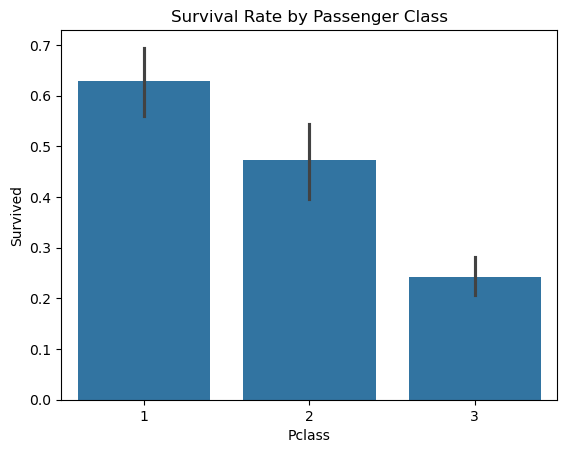

In [7]:
print(df.groupby('Sex')['Survived'].mean())

sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Passenger Class')
plt.show



<function matplotlib.pyplot.show(close=None, block=None)>

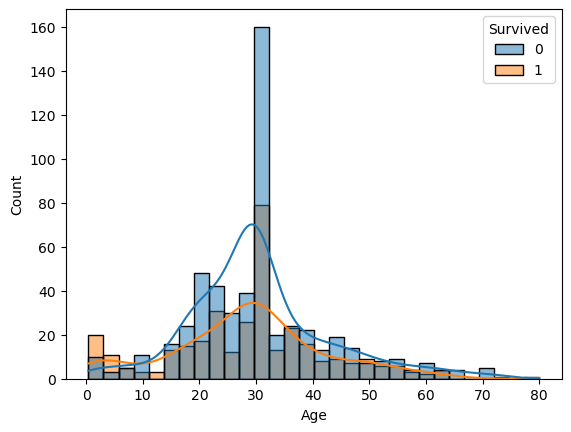

In [8]:
sns.histplot(data=df, x='Age', hue='Survived', kde=True)
plt.show
#0 is survived 1 is dead

In [9]:
#splitting the data
from sklearn.model_selection import train_test_split

x=df.drop(columns=['Survived'])
y=df['Survived']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"Training Set: {x_train.shape[0]} passengers")
print(f"Testing Set: {x_test.shape[0]} passengers")


Training Set: 712 passengers
Testing Set: 179 passengers


In [10]:
#Training
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Final Model Accuracy: {accuracy * 100:.2f}%')

Final Model Accuracy: 80.45%


<function matplotlib.pyplot.show(close=None, block=None)>

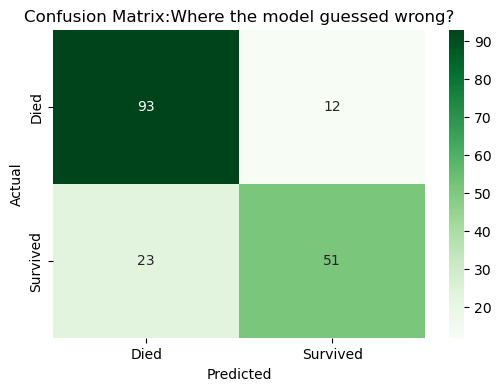

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d',
cmap='Greens', xticklabels=['Died', 'Survived'],
yticklabels=['Died', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix:Where the model guessed wrong?')
plt.show

In [13]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5],
    'min_samples_split': [2, 5],
    'criterion': ['gini', 'entropy']
}


grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')


grid_search.fit(x_train, y_train)

print(f"Best Parameters found: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_ * 100:.2f}%")

Best Parameters found: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
Best Cross-Validation Score: 83.14%


In [15]:
from sklearn.model_selection import cross_val_score

# This runs the model 5 times on different slices of data
scores = cross_val_score(model, x, y, cv=5)

print(f"All Scores: {scores}")
print(f"Average Accuracy: {scores.mean() * 100:.2f}%")
print(f"Standard Deviation: {scores.std():.4f}")




All Scores: [0.67597765 0.80337079 0.84831461 0.81460674 0.86516854]
Average Accuracy: 80.15%
Standard Deviation: 0.0666


In [16]:
import joblib

# Saves your "trained brain" to a file called titanic_model.pkl
joblib.dump(model, 'titanic_model.pkl')
print("Model saved successfully!")


Model saved successfully!
